## Multi-Asset Report Card Function

A reusable function that takes any ticker and date range, returns key risk-adjusted performance metrics, then visualizes comparison across multiple assets.

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
plt.style.use('ggplot')

### 1. Define the Report Card Function


In [8]:
def report_card (ticker, start, end):
    df = yf.download(ticker, start=start, end=end)
    df.columns = df.columns.get_level_values(0)
    df = df[['Close']]

    df['log_return'] = np.log(df.Close/df.Close.shift(1))
    
    trading_days = int(len(df.dropna()))

    
    total_volatility = df['log_return'].std() * np.sqrt(trading_days)
    total_sharpe = (df['log_return'].mean() / df['log_return'].std()) * np.sqrt(trading_days)
    total_return = (df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1  
    
    rolling_max = df['Close'].cummax()
    max_dd = ((df['Close'] - rolling_max) / rolling_max).min()

    return total_volatility, total_sharpe, total_return, max_dd  

### 2. Loop Through Multiple Assets

Apply the function and collect results into a clean DataFrame

In [35]:
tickers = ['EURUSD=X', 'USDJPY=X', 'GC=F', 'BTC-USD', 'AAPL', 'GBPUSD=x']

rows = []
        
for ticker in tickers:
    vol, sharpe, tr, dd = report_card(ticker, '2020-01-01', '2025-12-31')
    rows.append({'Ticker': ticker,
        'Total Vol': vol,
        'Total Sharpe': sharpe,
        'Total Return': tr,
        'Max Drawdown': dd
                })
report_df = pd.DataFrame(rows)  
report_df.set_index('Ticker', inplace=True)
report_df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Total Vol,Total Sharpe,Total Return,Max Drawdown
Ticker,,,,
EURUSD=X,0.186463,0.257568,0.049199,-0.222421
USDJPY=X,0.232839,1.552668,0.435513,-0.147494
GC=F,0.417828,2.520463,1.866579,-0.208725
BTC-USD,1.515266,1.655226,11.281666,-0.766346
AAPL,0.776137,1.709255,2.768270,-0.333605
GBPUSD=x,0.220726,0.084067,0.018729,-0.245961


### 3. Visualize Comparison

Bar chart comparing metrics across assets 

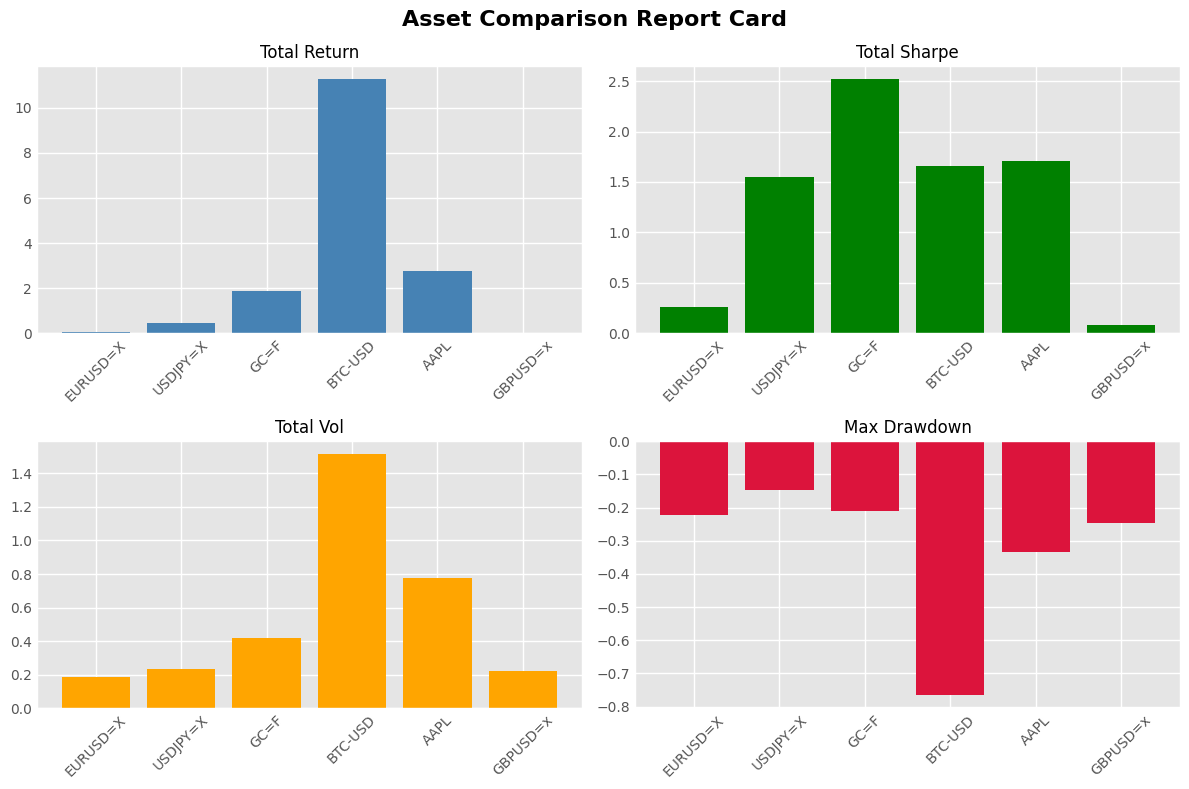

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Asset Comparison Report Card', fontsize=16, fontweight='bold')

metrics = ['Total Return', 'Total Sharpe', 'Total Vol', 'Max Drawdown']
colors = ['steelblue', 'green', 'orange', 'crimson']

for ax, metric, color in zip(axes.flat, metrics, colors):
    bars = ax.bar(report_df.index, report_df[metric], color=color)
    ax.set_title(metric, fontsize=12)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()